# 04 · Modelos físicos sobre ensayos de laboratorio (EPA Test Car List)

La Fuel Economy Guide describe el vehículo comercial; el **EPA Test Car List** describe el ensayo: peso equivalente
de ensayo, **coeficientes de resistencia al avance** (A, B, C), relación de grupo, potencia, ciclo y emisiones medidas.
Son exactamente las magnitudes que fija un banco de rodillos en homologación.

**Objetivo:** cuantificar cuánto del consumo y del CO₂ de cada ciclo explican estas magnitudes físicas, y si el mismo
enfoque se traslada a vehículos eléctricos.

**Fuente:** `data/raw/epa_test_car_list_2024_curated.xlsx`, extracto curado de 28 columnas del Test Car List 2024
(los vehículos con `Vehicle Type = Both` se asignaron a *Car* o *Truck*).

## Protocolo

| Elemento | Decisión |
|---|---|
| Calidad de datos | Eliminación de valores no físicos en `RND_ADJ_FE` y contrato `validate_epa_test_cars` |
| Unidad de agrupación | **Vehículo ensayado** (misma masa, potencia, cilindrada y coeficientes): cada uno aparece en varios ciclos |
| Partición | 25 % de los vehículos en prueba (`GroupShuffleSplit`) + CV aleatoria y agrupada (5 particiones) |
| Codificación del ciclo | Ordinal (referencia) frente a one-hot |

In [1]:
try:
    import vehicle_emissions  # instalado con `pip install -e .`
except ModuleNotFoundError:  # ejecución directa sin instalar el paquete
    import sys
    from pathlib import Path
    sys.path.insert(0, str(Path.cwd().parent / "src"))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 160)
RANDOM_STATE = 42

In [2]:
from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyRegressor
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import GroupShuffleSplit
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.preprocessing import MinMaxScaler, OneHotEncoder, OrdinalEncoder

from vehicle_emissions.data import FE_SENTINEL_THRESHOLD, load_epa_test_cars, vehicle_signature
from vehicle_emissions.evaluation import (evaluate_regressor, plot_correlation, plot_pred_vs_real, plot_residuals,
                                          results_table, top_correlations)
from vehicle_emissions.validation import DataValidationError, validate_epa_test_cars

raw = load_epa_test_cars()
print(f"{raw.shape[0]} ensayos × {raw.shape[1]} columnas")
raw.head(3)

4137 ensayos × 28 columnas


,Test Veh Displacement (L),Vehicle Type,Rated Horsepower,# of Cylinders and Rotors,Tested Transmission Type,# of Gears,Drive System Code,Equivalent Test Weight (lbs.),Axle Ratio,N/V Ratio,Test Fuel Type Cd,Test Category,THC (g/mi),CO (g/mi),CO2 (g/mi),NOx (g/mi),PM (g/mi),CH4 (g/mi),N2O (g/mi),RND_ADJ_FE,DT-Energy Economy Rating,Target Coef A (lbf),Target Coef B (lbf/mph),Target Coef C (lbf/mph**2),Set Coef A (lbf),Set Coef B (lbf/mph),Set Coef C (lbf/mph**2),Aftertreatment Device Cd
0,4.0,Car,680,8.0,Automatic,8,R,4500,3.08,24.8,61,FTP,0.0256,0.536,484.329,0.008,NaN,0.0089,0.0039,18.3,-0.35,53.24,0.2228,0.0221,5.67,0.0083,0.0221,TWC
1,4.0,Car,680,8.0,Automatic,8,R,4500,3.08,24.8,61,HWY,0.0007,0.040,283.235,0.007,NaN,NaN,NaN,31.3,-0.42,53.24,0.2228,0.0221,5.67,0.0083,0.0221,TWC
2,4.0,Truck,550,8.0,Automatic,9,4,5500,3.06,21.0,61,FTP,0.0146,0.120,521.260,0.009,NaN,0.0028,NaN,17.2,-2.11,60.68,-0.3286,0.0373,-4.88,-0.5318,0.0367,TWC


## 1. Calidad de datos

El contrato de calidad rechaza el extracto tal cual llega:

In [3]:
try:
    validate_epa_test_cars(raw)
except DataValidationError as e:
    print("DataValidationError:\n", e)

DataValidationError:
                 Comprobación    OK             Detalle
Sin centinelas en RND_ADJ_FE False máx=10000, ≥999: 22


In [4]:
sentinel = raw["RND_ADJ_FE"] >= FE_SENTINEL_THRESHOLD
print(f"Valores no físicos en RND_ADJ_FE: {sentinel.sum()}")
print(raw.loc[sentinel, "RND_ADJ_FE"].value_counts().to_string())
print(f"\nSi se dejan, el MSE de un modelo lineal lo dominan estos {sentinel.sum()} registros "
      f"(su varianza es {raw.loc[sentinel, 'RND_ADJ_FE'].var() / raw.loc[~sentinel, 'RND_ADJ_FE'].var():,.0f}× la del resto).")

Valores no físicos en RND_ADJ_FE: 22
RND_ADJ_FE
999.0      14
10000.0     6
4595.3      1
4599.1      1

Si se dejan, el MSE de un modelo lineal lo dominan estos 22 registros (su varianza es 8,804× la del resto).


In [5]:
df = raw[~sentinel].copy()
df["Vehicle ID"] = vehicle_signature(df)
validate_epa_test_cars(df)

,Comprobación,OK,Detalle
0,Sin centinelas en RND_ADJ_FE,True,"máx=987.5, ≥999: 0"
1,Consumo positivo,True,min=4.5
2,"Peso de ensayo en [1500, 12000] lb",True,"rango=[2375, 9000]"
3,Coeficiente A de carretera > 0,True,min=16.28


## 2. Vehículos de combustión

Se trabaja con el **combustible de certificación de gasolina** (código 61, el 79 % de los ensayos) para que el combustible sea homogéneo, y con los ciclos de combustión (FTP urbano, HWY carretera, US06 agresivo, SC03 con climatización).

In [6]:
comb = df[(df["Test Fuel Type Cd"] == 61) & (df["Test Category"] != "CD")].copy()
print(f"{len(comb)} ensayos · {comb['Vehicle ID'].nunique()} vehículos")
comb.groupby("Test Category")[["RND_ADJ_FE", "CO2 (g/mi)"]].median().round(1)

3137 ensayos · 1071 vehículos


,RND_ADJ_FE,CO2 (g/mi)
Test Category,,
FTP,26.0,341.0
HWY,39.2,226.4
SC03,23.2,384.6
US06,24.0,368.6


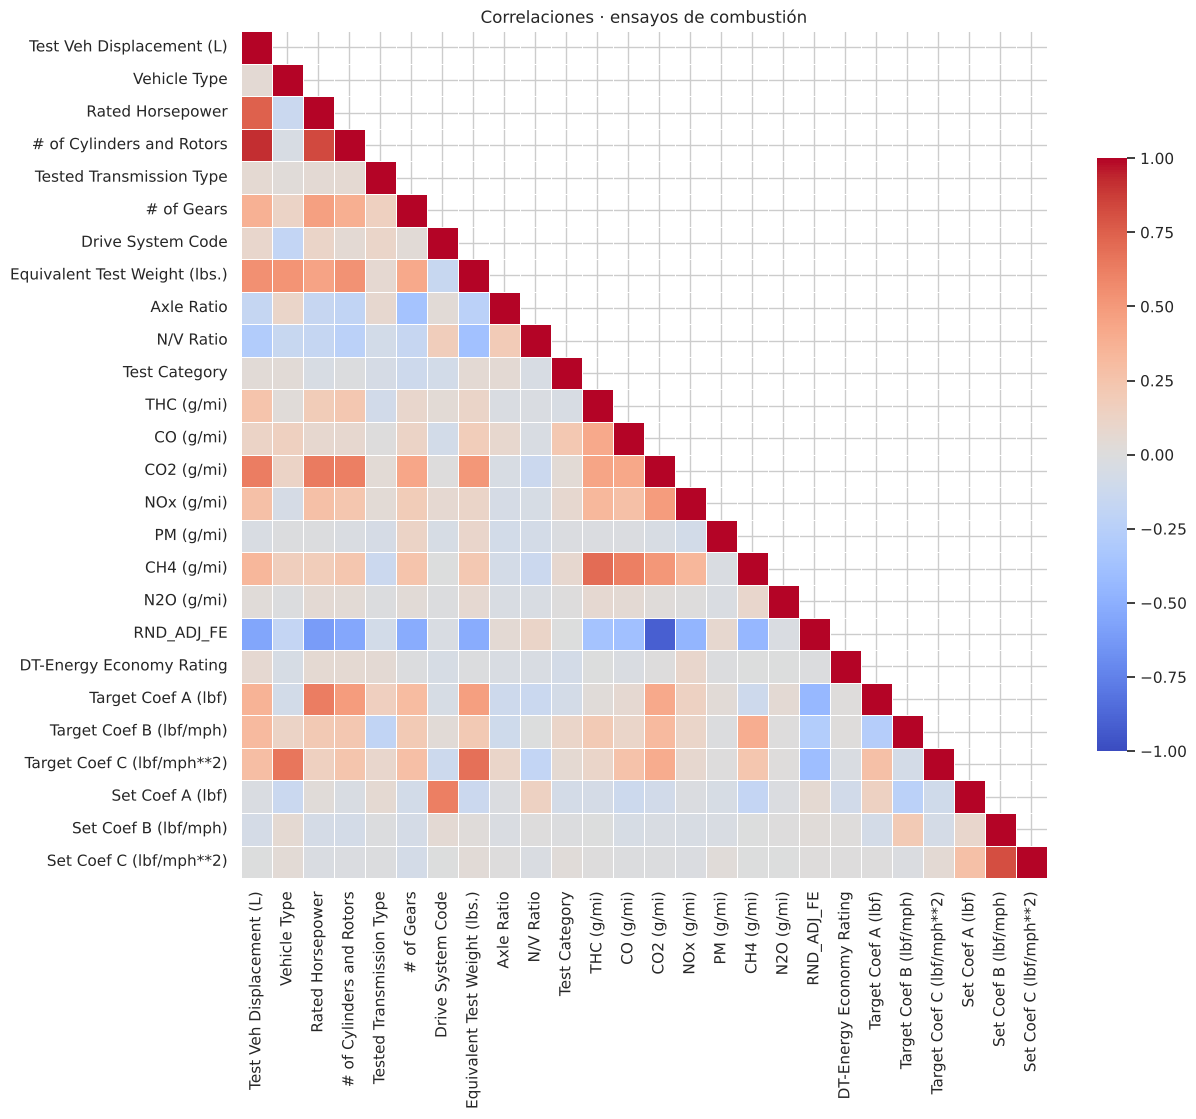

,Más positivas,Más negativas
0,Test Veh Displacement (L) ↔ # of Cylinders and...,CO2 (g/mi) ↔ RND_ADJ_FE: -0.908
1,Rated Horsepower ↔ # of Cylinders and Rotors: ...,Rated Horsepower ↔ RND_ADJ_FE: -0.610
2,Set Coef B (lbf/mph) ↔ Set Coef C (lbf/mph**2)...,Test Veh Displacement (L) ↔ RND_ADJ_FE: -0.555
3,Test Veh Displacement (L) ↔ Rated Horsepower: ...,# of Cylinders and Rotors ↔ RND_ADJ_FE: -0.552
4,THC (g/mi) ↔ CH4 (g/mi): 0.703,# of Gears ↔ RND_ADJ_FE: -0.522
5,Equivalent Test Weight (lbs.) ↔ Target Coef C ...,Equivalent Test Weight (lbs.) ↔ RND_ADJ_FE: -0...
6,Vehicle Type ↔ Target Coef C (lbf/mph**2): 0.659,NOx (g/mi) ↔ RND_ADJ_FE: -0.466
7,Rated Horsepower ↔ CO2 (g/mi): 0.637,CH4 (g/mi) ↔ RND_ADJ_FE: -0.450


In [7]:
enc_cols = ["Vehicle Type", "Tested Transmission Type", "Drive System Code", "Test Category"]
corr_df = comb.drop(columns=["Vehicle ID", "Test Fuel Type Cd"]).copy()
corr_df[enc_cols] = OrdinalEncoder().fit_transform(corr_df[enc_cols].astype(str))
corr_df = corr_df.drop(columns=["Aftertreatment Device Cd"])
corr_c = plot_correlation(corr_df, title="Correlaciones · ensayos de combustión", annot=False,
                          figsize=(13, 11), save_as="04_correlacion_combustion.png")
plt.show()
top_correlations(corr_c, 8)

In [8]:
NUM_C = ["Target Coef A (lbf)", "Target Coef B (lbf/mph)", "Target Coef C (lbf/mph**2)", "Test Veh Displacement (L)",
         "Equivalent Test Weight (lbs.)", "# of Gears", "Axle Ratio", "Rated Horsepower"]
CAT_C = ["Vehicle Type", "Test Category"]
C = comb[NUM_C + CAT_C + ["RND_ADJ_FE", "CO2 (g/mi)", "Vehicle ID"]].dropna().reset_index(drop=True)
idx_tr, idx_te = next(GroupShuffleSplit(n_splits=1, test_size=0.25, random_state=RANDOM_STATE).split(C, groups=C["Vehicle ID"]))
assert not set(C.loc[idx_tr, "Vehicle ID"]) & set(C.loc[idx_te, "Vehicle ID"])
print(f"{len(C)} ensayos completos · prueba: {len(idx_te)} ensayos de vehículos no vistos")

results = []
def run(name, model, feats, target, data=C, tr=idx_tr, te=idx_te):
    r = evaluate_regressor(name, model, data.loc[tr, feats], data.loc[te, feats], data.loc[tr, target],
                           data.loc[te, target], data[feats], data[target], groups=data["Vehicle ID"])
    r["_y_test"] = data.loc[te, target].to_numpy()
    results.append(r)
    return r

def pipe(est, ordinal=False):
    cat = OrdinalEncoder() if ordinal else OneHotEncoder(handle_unknown="ignore")
    return Pipeline([("pre", ColumnTransformer([("num", MinMaxScaler(), NUM_C), ("cat", cat, CAT_C)])), ("model", est)])

3137 ensayos completos · prueba: 729 ensayos de vehículos no vistos


### 2.1 Consumo por ciclo (mpg)

El ciclo no tiene orden natural (FTP, HWY, SC03, US06): codificarlo como un número fuerza al modelo lineal a suponer
que cada ciclo consume "un poco más" que el anterior. Se compara explícitamente con one-hot.

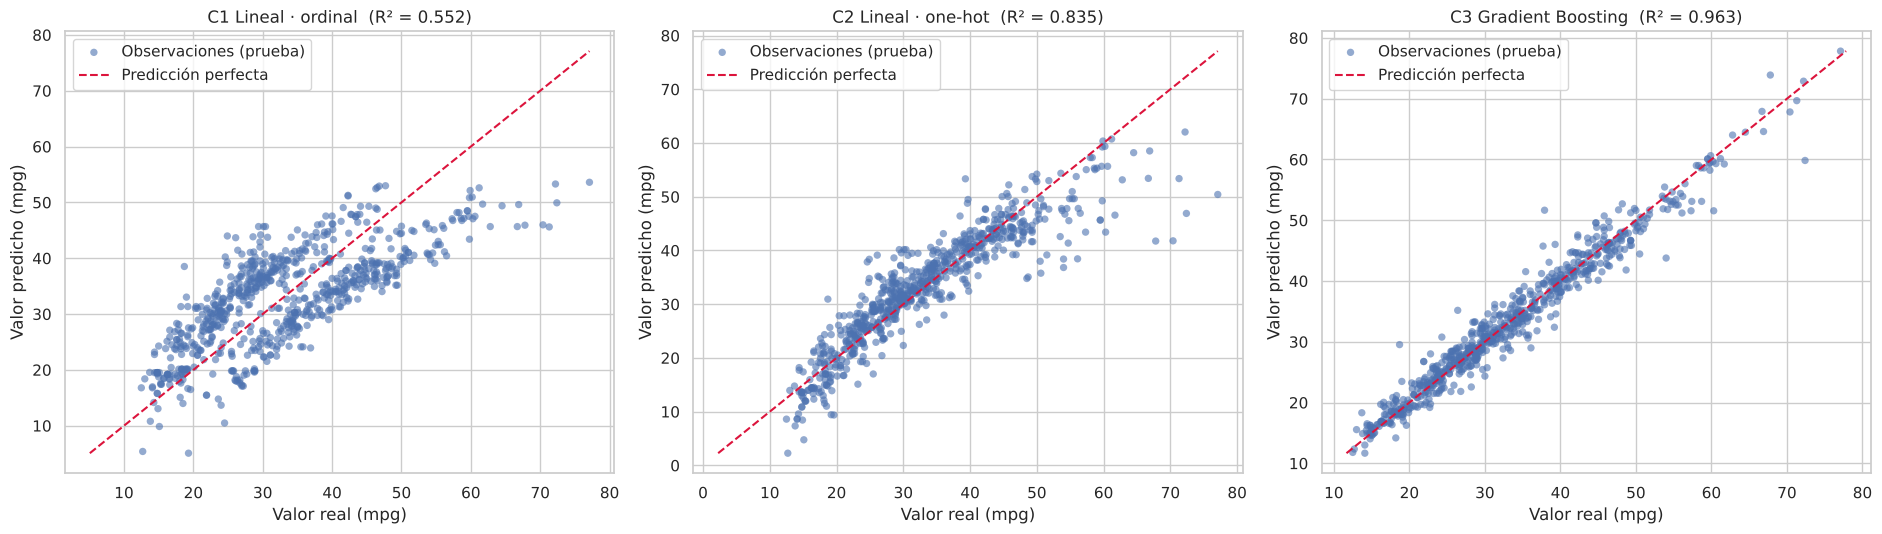

In [9]:
run("C0 Referencia · media", pipe(DummyRegressor()), NUM_C + CAT_C, "RND_ADJ_FE")
r1 = run("C1 Lineal · ciclo ordinal", pipe(LinearRegression(), ordinal=True), NUM_C + CAT_C, "RND_ADJ_FE")
r2 = run("C2 Lineal · ciclo one-hot", pipe(LinearRegression()), NUM_C + CAT_C, "RND_ADJ_FE")
r3 = run("C3 Gradient Boosting · ciclo one-hot", pipe(GradientBoostingRegressor(n_estimators=400, max_depth=4,
         learning_rate=0.05, subsample=0.8, random_state=RANDOM_STATE)), NUM_C + CAT_C, "RND_ADJ_FE")
fig, axs = plt.subplots(1, 3, figsize=(19, 5.5))
for ax, r, t in zip(axs, [r1, r2, r3], ["C1 Lineal · ordinal", "C2 Lineal · one-hot", "C3 Gradient Boosting"]):
    plot_pred_vs_real(r["_y_test"], r["_y_pred"], t, "(mpg)", ax=ax)
fig.tight_layout(); fig.savefig("../reports/figures/04_combustion_mpg.png", dpi=150, bbox_inches="tight")
plt.show()

### 2.2 Emisiones de CO₂ medidas (g/mi)

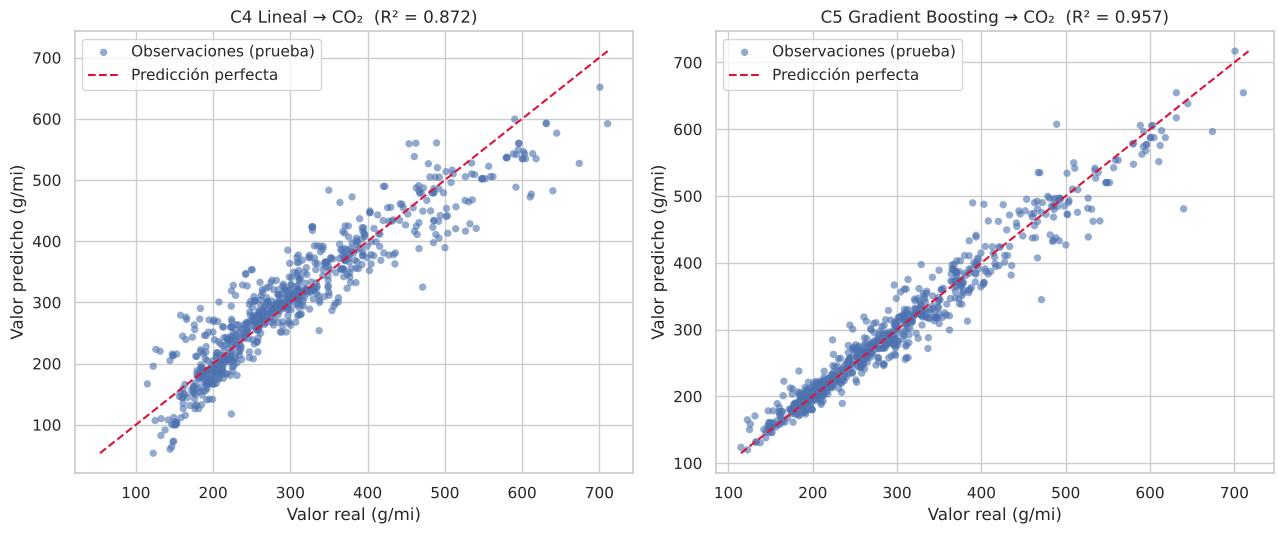

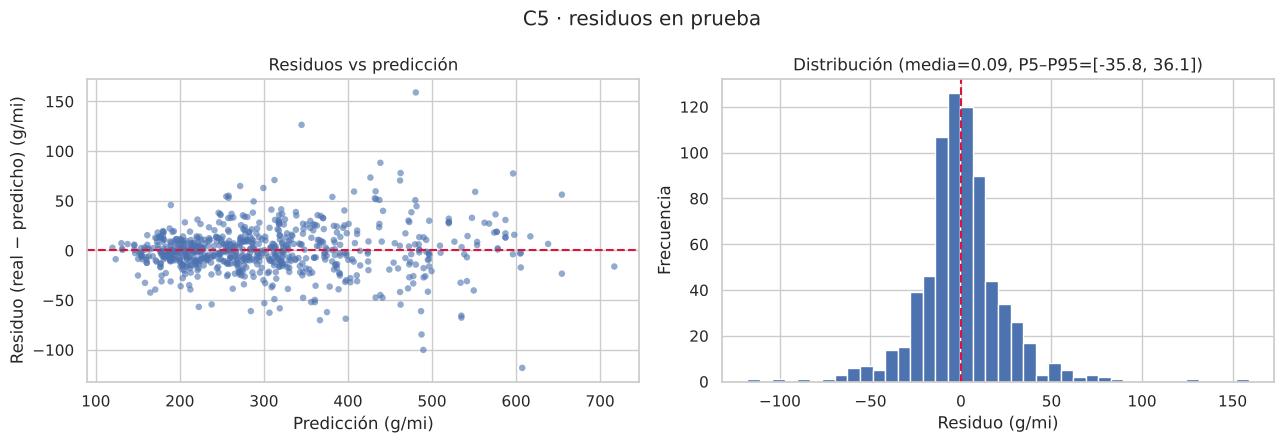

In [10]:
r4 = run("C4 Lineal · one-hot → CO₂", pipe(LinearRegression()), NUM_C + CAT_C, "CO2 (g/mi)")
r5 = run("C5 Gradient Boosting · one-hot → CO₂", pipe(GradientBoostingRegressor(n_estimators=400, max_depth=4,
         learning_rate=0.05, subsample=0.8, random_state=RANDOM_STATE)), NUM_C + CAT_C, "CO2 (g/mi)")
fig, axs = plt.subplots(1, 2, figsize=(13, 5.5))
plot_pred_vs_real(r4["_y_test"], r4["_y_pred"], "C4 Lineal → CO₂", "(g/mi)", ax=axs[0])
plot_pred_vs_real(r5["_y_test"], r5["_y_pred"], "C5 Gradient Boosting → CO₂", "(g/mi)", ax=axs[1])
fig.tight_layout(); fig.savefig("../reports/figures/04_combustion_co2.png", dpi=150, bbox_inches="tight")
plt.show()
plot_residuals(r5["_y_test"], r5["_y_pred"], "(g/mi)", "C5 · residuos en prueba", save_as="04_C5_residuos.png")
plt.show()

In [11]:
results_table(results)

,MAE,RMSE,R2,R2 CV,± std,R2 CV agrupada,MAE CV agrupada
Experimento,,,,,,,
C0 Referencia · media,9.452,11.760,-0.004,-0.002,0.002,-0.005,9.520
C1 Lineal · ciclo ordinal,6.910,7.857,0.552,0.552,0.034,0.553,6.922
C2 Lineal · ciclo one-hot,3.298,4.775,0.835,0.831,0.010,0.830,3.400
C3 Gradient Boosting · ciclo one-hot,1.594,2.269,0.963,0.973,0.004,0.966,1.570
C4 Lineal · one-hot → CO₂,30.433,40.851,0.872,0.861,0.009,0.862,31.888
C5 Gradient Boosting · one-hot → CO₂,16.187,23.654,0.957,0.946,0.014,0.943,17.608


## 3. Vehículos eléctricos

Ensayos con electricidad (código 62). Todos pertenecen al ciclo `CD` (*charge depleting*) y el consumo está en mpge.
Se retiran las variables sin sentido para un eléctrico (cilindrada, marchas, emisiones).

508 ensayos · 225 vehículos · ciclos con consumo informado: ['CD']


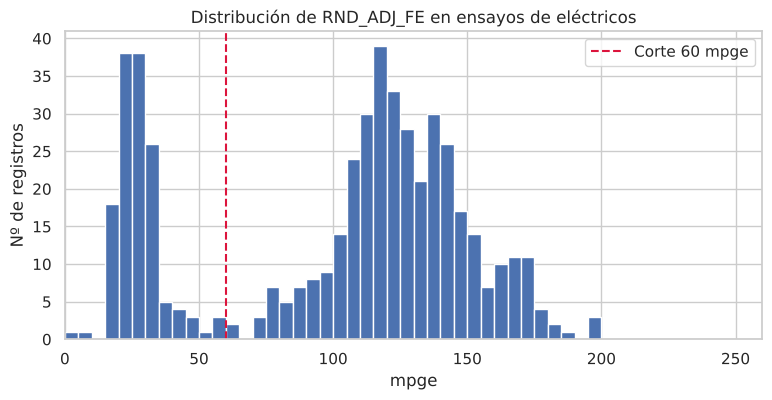

< 60 mpge: 138 · 60–250: 366 · > 250: 4


In [12]:
ev = df[df["Test Fuel Type Cd"] == 62].copy()
NUM_E = ["Target Coef A (lbf)", "Target Coef B (lbf/mph)", "Target Coef C (lbf/mph**2)", "Rated Horsepower",
         "Equivalent Test Weight (lbs.)"]
CAT_E = ["Vehicle Type"]
E = ev[NUM_E + CAT_E + ["RND_ADJ_FE", "Vehicle ID"]].dropna().reset_index(drop=True)
print(f"{len(E)} ensayos · {E['Vehicle ID'].nunique()} vehículos · "
      f"ciclos con consumo informado: {ev.loc[ev['RND_ADJ_FE'].notna(), 'Test Category'].unique().tolist()}")

fig, ax = plt.subplots(figsize=(9, 4))
ax.hist(E["RND_ADJ_FE"], bins=np.arange(0, 260, 5), color="#4C72B0")
ax.axvline(60, color="crimson", ls="--", label="Corte 60 mpge")
ax.set(title="Distribución de RND_ADJ_FE en ensayos de eléctricos", xlabel="mpge", ylabel="Nº de registros", xlim=(0, 260))
ax.legend(); fig.savefig("../reports/figures/04_histograma_electricos.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"< 60 mpge: {(E['RND_ADJ_FE'] < 60).sum()} · 60–250: {E['RND_ADJ_FE'].between(60, 250).sum()} · > 250: {(E['RND_ADJ_FE'] > 250).sum()}")

La distribución es **bimodal**: un grupo principal entre 80 y 200 mpge (consumo típico de un eléctrico) y otro
por debajo de 60 que corresponde a otro tipo de registro dentro del mismo ciclo. Ninguna variable disponible distingue
ambos grupos, así que se evalúa el modelo con todos los registros y restringido al grupo principal.

In [13]:
def ev_pipe(est):
    return Pipeline([("pre", ColumnTransformer([("num", MinMaxScaler(), NUM_E),
                                                ("cat", OneHotEncoder(handle_unknown="ignore"), CAT_E)])), ("model", est)])

ev_results = []
for label, data in [("todos los registros", E), ("grupo principal 60–250 mpge", E[E["RND_ADJ_FE"].between(60, 250)].reset_index(drop=True))]:
    tr, te = next(GroupShuffleSplit(n_splits=1, test_size=0.25, random_state=RANDOM_STATE).split(data, groups=data["Vehicle ID"]))
    for mname, est in [("Lineal", LinearRegression()),
                       ("Gradient Boosting", GradientBoostingRegressor(n_estimators=300, max_depth=3, learning_rate=0.05,
                                                                      subsample=0.8, random_state=RANDOM_STATE))]:
        r = evaluate_regressor(f"EV {mname} · {label}", ev_pipe(est), data.loc[tr, NUM_E + CAT_E], data.loc[te, NUM_E + CAT_E],
                               data.loc[tr, "RND_ADJ_FE"], data.loc[te, "RND_ADJ_FE"], data[NUM_E + CAT_E],
                               data["RND_ADJ_FE"], groups=data["Vehicle ID"])
        r["_y_test"] = data.loc[te, "RND_ADJ_FE"].to_numpy()
        ev_results.append(r)
ev_tab = results_table(ev_results)
ev_tab

,MAE,RMSE,R2,R2 CV,± std,R2 CV agrupada,MAE CV agrupada
Experimento,,,,,,,
EV Lineal · todos los registros,39.221,55.185,-0.342,0.012,0.055,-1.083,46.619
EV Gradient Boosting · todos los registros,26.354,39.575,0.310,0.823,0.136,0.276,30.177
EV Lineal · grupo principal 60–250 mpge,10.887,13.504,0.673,0.575,0.124,-0.217,14.006
EV Gradient Boosting · grupo principal 60–250 mpge,10.985,14.205,0.638,0.670,0.081,0.665,10.511


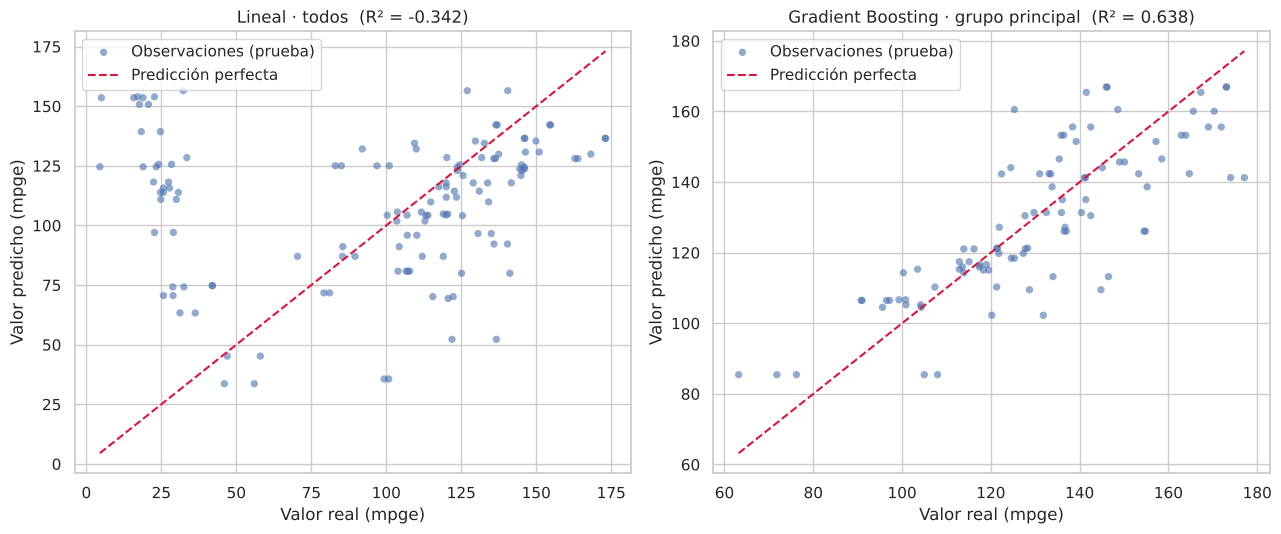

In [14]:
fig, axs = plt.subplots(1, 2, figsize=(13, 5.5))
plot_pred_vs_real(ev_results[0]["_y_test"], ev_results[0]["_y_pred"], "Lineal · todos", "(mpge)", ax=axs[0])
plot_pred_vs_real(ev_results[3]["_y_test"], ev_results[3]["_y_pred"], "Gradient Boosting · grupo principal", "(mpge)", ax=axs[1])
fig.tight_layout(); fig.savefig("../reports/figures/04_electricos.png", dpi=150, bbox_inches="tight")
plt.show()

## 4. Conclusiones

* **La calidad de datos es un requisito, no un detalle.** 22 registros con marcadores no físicos (999, 10 000) tenían
  una varianza miles de veces mayor que el resto y bastaban para invalidar cualquier métrica de error cuadrático.
  El contrato `validate_epa_test_cars` los bloquea antes de modelar.
* **Las magnitudes del ensayo explican casi todo el consumo de un vehículo de combustión.** Con masa equivalente,
  coeficientes de resistencia al avance, cilindrada, potencia y ciclo, un Gradient Boosting alcanza **R² ≈ 0,97 en mpg y
  ≈ 0,94 en CO₂** sobre vehículos no vistos, con un error medio de ≈ 1,6 mpg y ≈ 18 g/mi.
* **Codificar bien una sola variable cambia el resultado:** pasar el ciclo de ordinal a one-hot sube el R² lineal de
  0,55 a 0,83, porque los ciclos no tienen orden natural.
* **En eléctricos, la validación aleatoria engaña.** Cada vehículo aparece varias veces; con `KFold` el Gradient Boosting
  obtiene R² ≈ 0,82, pero con `GroupKFold` por vehículo cae a ≈ 0,28: el modelo memorizaba vehículos, no aprendía
  física. Restringido al grupo principal de registros (60–250 mpge), la estimación honesta es R² ≈ 0,67 con un error
  medio de ≈ 10,5 mpge.
* **Siguiente paso para eléctricos:** incorporar capacidad y química de batería, eficiencia del tren motor y el tipo
  de registro dentro del ciclo `CD`; sin ellas, las variables de carretera sólo explican parte de la variabilidad.